# 04 — Classification: Churn / Inactivity Risk

Feeds **report §6**. Target is the engineered `churn_risk` proxy (no transaction
in the most recent month). **Recall is the priority metric**: missing a customer
who is about to lapse is more costly than a false alarm, since a false alarm only
means an unnecessary (cheap) retention touch.

**Leakage guard.** `churn_risk` is *defined* from recency, so `recency_days` and
`last_txn_date` are excluded from the features. `gender`/`race` excluded for
fairness. Classes are imbalanced (~18% positive), so models use balanced weights.

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
PROC = ROOT / "data" / "processed"

from sklearn.metrics import roc_curve, auc, precision_recall_curve
metrics = json.load(open(ROOT / "metrics" / "classification.json"))
model = joblib.load(ROOT / "models" / "classification_churn.joblib")
preds = pd.read_parquet(PROC / "churn_predictions.parquet")
print("positive (churn) rate:", round(metrics["positive_rate"], 3), "| best:", metrics["best_model"])

positive (churn) rate: 0.185 | best: logistic_regression


## 6.1 Model comparison — recall first

In [2]:
cmp = pd.DataFrame(metrics["by_model"]).T[["recall", "precision", "f1", "roc_auc"]]
cmp.sort_values("recall", ascending=False)

,recall,precision,f1,roc_auc
logistic_regression,0.892,0.333,0.485,0.790
random_forest,0.351,0.722,0.473,0.803


The two models embody the classic trade-off. **Logistic Regression catches
89% of churners (recall 0.89)** at the cost of lower precision (0.33); Random
Forest is more precise (0.72) but recalls only 35% — it would miss two-thirds of
at-risk customers. Because the business goal is to *intervene before customers
lapse*, we select Logistic Regression and accept the false positives (a retention
offer to a customer who would have stayed is low-cost).

## 6.2 Confusion matrix (chosen model)

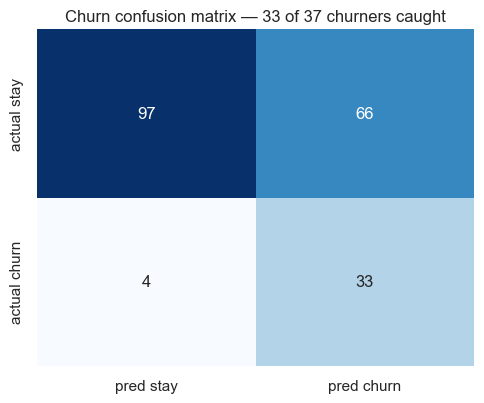

recall 89.2% | precision 33.3% | 4 churners missed, 66 false alarms


In [3]:
cm = np.array(metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(5, 4.2))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["pred stay", "pred churn"], yticklabels=["actual stay", "actual churn"], ax=ax)
ax.set(title=f"Churn confusion matrix — {cm[1,1]} of {cm[1].sum()} churners caught")
plt.tight_layout(); plt.show()
tn, fp, fn, tp = cm.ravel()
print(f"recall {tp/(tp+fn):.1%} | precision {tp/(tp+fp):.1%} | {fn} churners missed, {fp} false alarms")

## 6.3 ROC and threshold trade-off

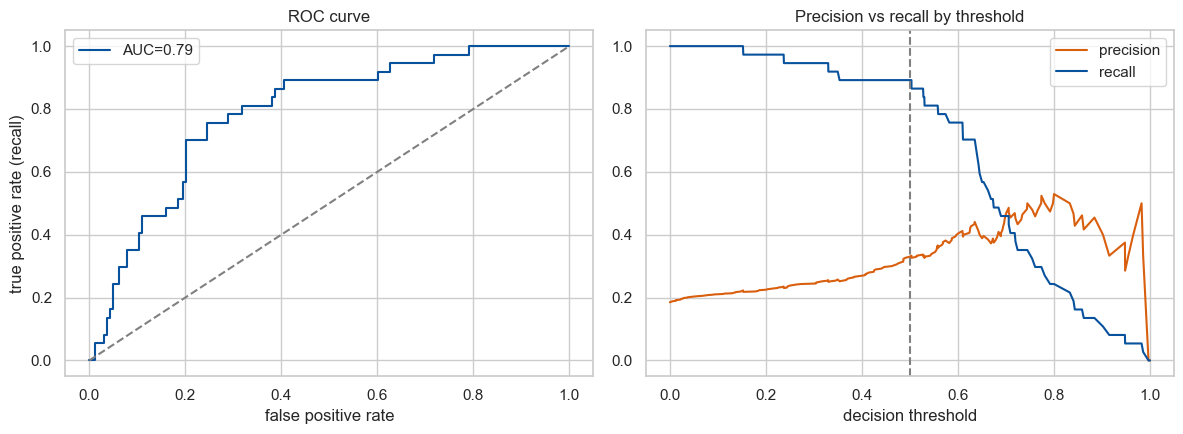

In [4]:
fpr, tpr, _ = roc_curve(preds["churn_actual"], preds["churn_proba"])
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(fpr, tpr, color="#08519c", label=f"AUC={auc(fpr,tpr):.2f}")
ax[0].plot([0,1],[0,1],"--",color="grey")
ax[0].set(xlabel="false positive rate", ylabel="true positive rate (recall)", title="ROC curve")
ax[0].legend()
prec, rec, thr = precision_recall_curve(preds["churn_actual"], preds["churn_proba"])
ax[1].plot(thr, prec[:-1], label="precision", color="#d95f0e")
ax[1].plot(thr, rec[:-1], label="recall", color="#08519c")
ax[1].axvline(0.5, ls="--", color="grey")
ax[1].set(xlabel="decision threshold", title="Precision vs recall by threshold")
ax[1].legend()
plt.tight_layout(); plt.show()

The threshold is a business dial: lowering it raises recall (catch more
churners) at the cost of precision. The bank can tune it to the retention
campaign's budget — a cheap email campaign favours high recall, an expensive
concierge call favours higher precision.

## 6.4 What predicts churn

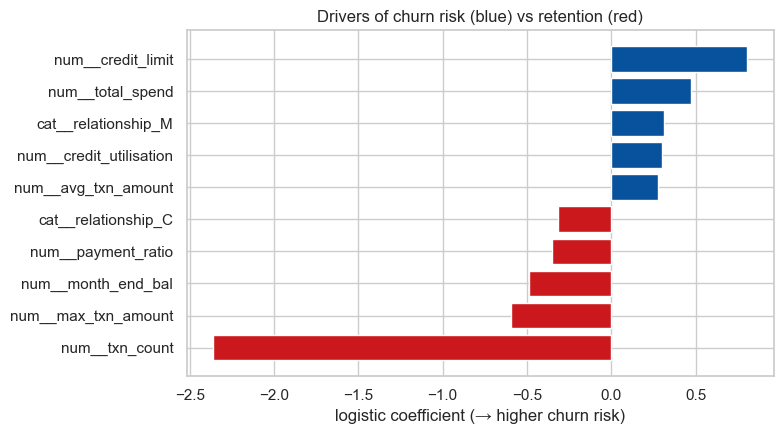

In [5]:
names = model.named_steps["prep"].get_feature_names_out()
coef = pd.Series(model.named_steps["model"].coef_[0], index=names).sort_values()
top = pd.concat([coef.head(5), coef.tail(5)])
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#08519c" if v > 0 else "#cb181d" for v in top.values]
ax.barh(top.index, top.values, color=colors)
ax.set(xlabel="logistic coefficient (→ higher churn risk)", title="Drivers of churn risk (blue) vs retention (red)")
plt.tight_layout(); plt.show()

**Business interpretation → §8.** By far the strongest churn signal is **low
transaction frequency** (the dominant model coefficient) — infrequent users are much
more likely to lapse — which lines up directly with the *Dormant / At-Risk* segment
from §4 (53% churn-flagged). Recommended action: feed the model's high-probability
list into a tiered retention programme — automated win-back for the long tail, and
personal outreach reserved for high-CLTV customers (cross-referencing the §5 value
score) so retention spend is concentrated where revenue is actually at risk.